# Task 1.1 – Gauss-Seidel Solver: Python List vs `array` vs NumPy

Benchmark the **same** Gauss-Seidel kernel implemented with three different data structures and measure how the wall-clock time scales with grid size $N$.


- Grid: $N \times N$, unit square, zero boundary conditions  
- Interior: random initial values  
- 100 Gauss-Seidel iterations per measurement  
- Grid sizes tested: $N \in \{16, 32, 64, 128, 256\}$

In [2]:
from array import array
import random
import time

import numpy as np
import matplotlib.pyplot as plt

ITERS      = 100
GRID_SIZES = [16, 32, 64, 128, 256]
SEED       = 42

## Grid Initialisation

Each helper creates an $N \times N$ grid with the same random values and zero boundary conditions, stored in the respective data structure.

In [3]:
def make_grid_list(N):
    random.seed(SEED)
    f = [[0.0] * N for _ in range(N)]
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            f[i][j] = random.random()
    return f

def make_grid_array(N):
    f = make_grid_list(N)
    return array('d', (f[i][j] for i in range(N) for j in range(N))), N

def make_grid_numpy(N):
    rng = np.random.default_rng(SEED)
    f = np.zeros((N, N))
    f[1:-1, 1:-1] = rng.random((N - 2, N - 2))  # only fill interior
    return f


In [4]:
def gauss_seidel_list(f):
    N = len(f)
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            f[i][j] = 0.25 * (f[i][j+1] + f[i][j-1] +
                               f[i+1][j] + f[i-1][j])
    return f

def gauss_seidel_array(f, N):
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            idx = i * N + j
            f[idx] = 0.25 * (f[idx + 1] + f[idx - 1] +
                              f[idx + N] + f[idx - N])
    return f

def gauss_seidel_numpy(f):
    for i in range(1, f.shape[0] - 1):
        for j in range(1, f.shape[1] - 1):
            f[i, j] = 0.25 * (f[i, j+1] + f[i, j-1] +
                               f[i+1, j] + f[i-1, j])
    return f

## Benchmark


In [5]:
times_list  = []
times_array = []
times_numpy = []

for N in GRID_SIZES:
    print(f"N = {N:4d} ...", end="  ", flush=True)

    # list-of-lists
    f = make_grid_list(N)
    t0 = time.perf_counter()
    for _ in range(ITERS):
        gauss_seidel_list(f)
    times_list.append(time.perf_counter() - t0)

    # flat array('d')
    f, _ = make_grid_array(N)
    t0 = time.perf_counter()
    for _ in range(ITERS):
        gauss_seidel_array(f, N)
    times_array.append(time.perf_counter() - t0)

    # NumPy 2-D array
    f = make_grid_numpy(N)
    t0 = time.perf_counter()
    for _ in range(ITERS):
        gauss_seidel_numpy(f)
    times_numpy.append(time.perf_counter() - t0)

    print(f"list={times_list[-1]:.4f}s   array={times_array[-1]:.4f}s   numpy={times_numpy[-1]:.4f}s")

N =   16 ...  list=0.0076s   array=0.0082s   numpy=0.0106s
N =   32 ...  list=0.0105s   array=0.0166s   numpy=0.0474s
N =   64 ...  list=0.0436s   array=0.0725s   numpy=0.1980s
N =  128 ...  list=0.1809s   array=0.3044s   numpy=0.8173s
N =  256 ...  list=0.7657s   array=1.2017s   numpy=3.2487s


## Performance Plot

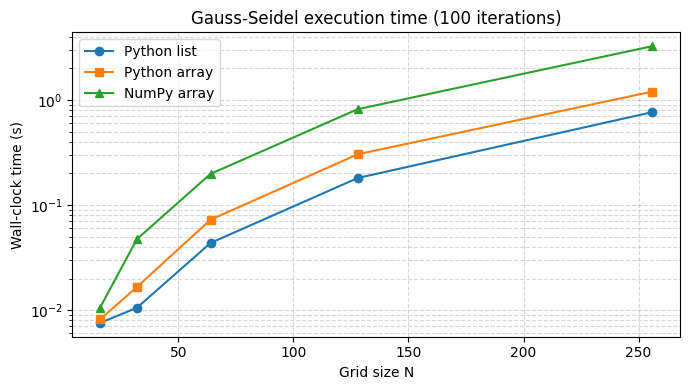

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(GRID_SIZES, times_list,  "o-", label="Python list")
ax.plot(GRID_SIZES, times_array, "s-", label="Python array")
ax.plot(GRID_SIZES, times_numpy, "^-", label="NumPy array")
ax.set_xlabel("Grid size N")
ax.set_ylabel("Wall-clock time (s)")
ax.set_title(f"Gauss-Seidel execution time ({ITERS} iterations)")
ax.set_yscale("log")
ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


---
## Task 1.2 – Profile the Code


We profile `gauss_seidel_list` on a 128×128 grid for 100 iterations, the baseline that will guide optimisation.

### cProfile

In [9]:
import cProfile
import pstats
import io

N_PROF = 128

def run_list(iters=ITERS):
    f = make_grid_list(N_PROF)
    for _ in range(iters):
        gauss_seidel_list(f)

pr = cProfile.Profile()
pr.enable()
run_list()
pr.disable()

stream = io.StringIO()
ps = pstats.Stats(pr, stream=stream)
ps.sort_stats("tottime")         
ps.print_stats("ipykernel")       
print(stream.getvalue())


         16783 function calls (16778 primitive calls) in 0.337 seconds

   Ordered by: internal time
   List reduced from 138 to 10 due to restriction <'ipykernel'>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      100    0.229    0.002    0.229    0.002 /var/folders/66/s_wdz_l53qz4tp6lwx4654nh0000gn/T/ipykernel_30173/2194687373.py:1(gauss_seidel_list)
        1    0.002    0.002    0.004    0.004 /var/folders/66/s_wdz_l53qz4tp6lwx4654nh0000gn/T/ipykernel_30173/2803086279.py:1(make_grid_list)
        1    0.000    0.000    0.177    0.177 /var/folders/66/s_wdz_l53qz4tp6lwx4654nh0000gn/T/ipykernel_30173/1977942482.py:1(<module>)
        1    0.000    0.000    0.177    0.177 /var/folders/66/s_wdz_l53qz4tp6lwx4654nh0000gn/T/ipykernel_30173/1977942482.py:7(run_list)
        2    0.000    0.000    0.063    0.032 /Users/ermiaghaffari/Desktop/DD2358/.venv/lib/python3.14/site-packages/ipykernel/iostream.py:158(_handle_event)
        2    0.000    0.000    0.043    0

### line_profiler

`line_profiler` shows the time spent on **every individual line** inside the function.  
Install once with `pip install line_profiler`, then use the `%lprun` magic.

In [11]:
%load_ext line_profiler

f_prof = make_grid_list(N_PROF)
%lprun -f gauss_seidel_list run_list()

Timer unit: 1e-09 s

Total time: 2.86176 s
File: /var/folders/66/s_wdz_l53qz4tp6lwx4654nh0000gn/T/ipykernel_30173/2194687373.py
Function: gauss_seidel_list at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def gauss_seidel_list(f):
     2       100      74000.0    740.0      0.0      N = len(f)
     3     12700    3735000.0    294.1      0.1      for i in range(1, N - 1):
     4   1600200  463877000.0    289.9     16.2          for j in range(1, N - 1):
     5   4762800 1504352000.0    315.9     52.6              f[i][j] = 0.25 * (f[i][j+1] + f[i][j-1] +
     6   3175200  889612000.0    280.2     31.1                                 f[i+1][j] + f[i-1][j])
     7       100     107000.0   1070.0      0.0      return f

### What the profiling tells us

**cProfile** show that virtually all time is spent inside `gauss_seidel_list` and the function call itself is the hotspot.

**line_profiler** reveals that the single update line:

```python
f[i][j] = 0.25 * (f[i][j+1] + f[i][j-1] + f[i+1][j] + f[i-1][j])
```

accounts for most of all time. The `for` loop lines consume the remaining.


---
## Task 1.3 – Cython Annotation





In [ ]:
%%writefile gauss_seidel_annotate.pyx

def gauss_seidel(f):
    N = len(f)
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            f[i][j] = 0.25 * (f[i][j+1] + f[i][j-1] +
                               f[i+1][j] + f[i-1][j])
    return f

Writing gauss_seidel_annotate.pyx


In [17]:
import subprocess, pathlib

result = subprocess.run(
    ["cython", "-a", "gauss_seidel_annotate.pyx"],
    capture_output=True, text=True
)
print(result.stdout or "Done.")
if result.returncode != 0:
    print("STDERR:", result.stderr)

Done.


### Reading the annotation report

All the lines are still yellow. 

---
## Task 1.4 – Cython Optimisation

The annotation showed that every line in the plain Python loop is yellow (Python C-API overhead).  
The fix is to add **static type declarations**:

- `double[:, :]` typed memoryview which helps with direct C-level buffer access, no Python indexing
- `cdef int i, j` → loop variables become C `int`, no Python integer boxing
- `nogil` + `boundscheck(False)` → further reduces overhead

We compile the typed `.pyx`, then benchmark it against the three Task 1.1 implementations.

In [19]:
%%writefile cgs.pyx
# cython: boundscheck=False, wraparound=False, cdivision=True
import numpy as np

def gauss_seidel_cython(double[:, :] f):
    cdef int N = f.shape[0]
    cdef int i, j
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            f[i, j] = 0.25 * (f[i, j+1] + f[i, j-1] +
                               f[i+1, j] + f[i-1, j])
    return f

Writing cgs.pyx


In [20]:
%%writefile setup_cgs.py
from setuptools import setup
from Cython.Build import cythonize
import numpy as np

setup(
    ext_modules=cythonize("cgs.pyx", compiler_directives={"language_level": "3"}),
    include_dirs=[np.get_include()],
)

Writing setup_cgs.py


In [22]:
import subprocess, sys

res = subprocess.run(
    [sys.executable, "setup_cgs.py", "build_ext", "--inplace"],
    capture_output=True, text=True
)
print(res.stdout[-1500:] if len(res.stdout) > 1500 else res.stdout)
if res.returncode != 0:
    print("STDERR:", res.stderr[-1000:])

Compiling cgs.pyx because it changed.
[1/1] Cythonizing cgs.pyx
running build_ext
building 'cgs' extension
creating build/temp.macosx-15.0-arm64-cpython-314
clang -fno-strict-overflow -Wsign-compare -Wunreachable-code -fno-common -dynamic -DNDEBUG -g -O3 -Wall -I/Users/ermiaghaffari/Desktop/DD2358/.venv/lib/python3.14/site-packages/numpy/_core/include -I/Users/ermiaghaffari/Desktop/DD2358/.venv/include -I/opt/homebrew/opt/python@3.14/Frameworks/Python.framework/Versions/3.14/include/python3.14 -c cgs.c -o build/temp.macosx-15.0-arm64-cpython-314/cgs.o
creating build/lib.macosx-15.0-arm64-cpython-314
clang -bundle -undefined dynamic_lookup build/temp.macosx-15.0-arm64-cpython-314/cgs.o -o build/lib.macosx-15.0-arm64-cpython-314/cgs.cpython-314-darwin.so
copying build/lib.macosx-15.0-arm64-cpython-314/cgs.cpython-314-darwin.so -> 



In [23]:
import importlib, cgs
importlib.reload(cgs)
from cgs import gauss_seidel_cython

times_cython = []

for N in GRID_SIZES:
    f = make_grid_numpy(N)    
    t0 = time.perf_counter()
    for _ in range(ITERS):
        gauss_seidel_cython(f)
    times_cython.append(time.perf_counter() - t0)
    print(f"N = {N:4d}  cython={times_cython[-1]:.4f}s  "
          f"speedup_vs_list={times_list[GRID_SIZES.index(N)] / times_cython[-1]:.1f}x")

N =   16  cython=0.0002s  speedup_vs_list=36.7x
N =   32  cython=0.0006s  speedup_vs_list=16.6x
N =   64  cython=0.0039s  speedup_vs_list=11.2x
N =  128  cython=0.0105s  speedup_vs_list=17.1x
N =  256  cython=0.0416s  speedup_vs_list=18.4x


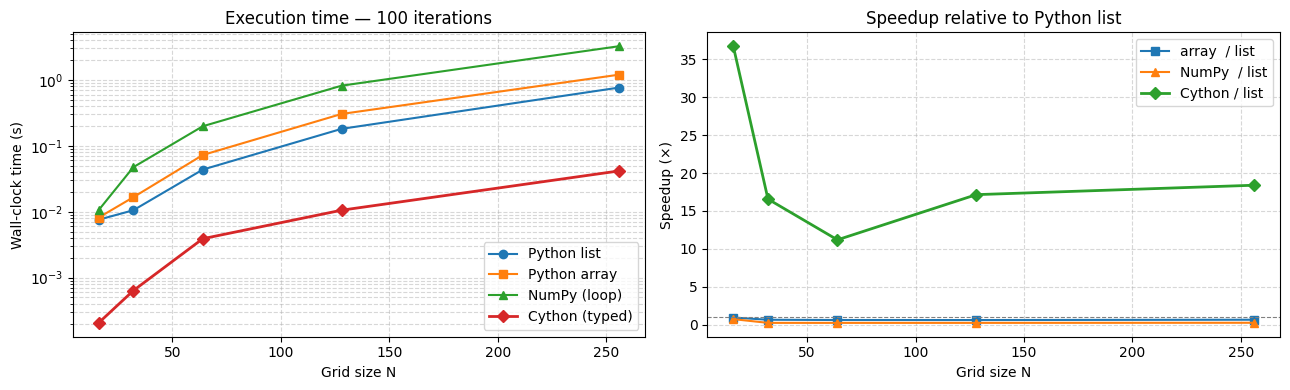

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: absolute time ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(GRID_SIZES, times_list,   "o-",  label="Python list")
ax.plot(GRID_SIZES, times_array,  "s-",  label="Python array")
ax.plot(GRID_SIZES, times_numpy,  "^-",  label="NumPy (loop)")
ax.plot(GRID_SIZES, times_cython, "D-",  label="Cython (typed)", linewidth=2)
ax.set_xlabel("Grid size N")
ax.set_ylabel("Wall-clock time (s)")
ax.set_title(f"Execution time — {ITERS} iterations")
ax.set_yscale("log")
ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.5)

# ── Right: speedup vs Python list ─────────────────────────────────────────
ax = axes[1]
ax.plot(GRID_SIZES, [l/a for l, a in zip(times_list, times_array)],  "s-", label="array  / list")
ax.plot(GRID_SIZES, [l/n for l, n in zip(times_list, times_numpy)],  "^-", label="NumPy  / list")
ax.plot(GRID_SIZES, [l/c for l, c in zip(times_list, times_cython)], "D-", label="Cython / list", linewidth=2)
ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Grid size N")
ax.set_ylabel("Speedup (×)")
ax.set_title("Speedup relative to Python list")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

---
## Task 1.5 – PyTorch / GPU port using the Jacobi scheme



In [ ]:
def jacobi_numpy(f):

    f_new = 0.25 * (np.roll(f,  1, axis=0) +   # f[i-1, j]
                    np.roll(f, -1, axis=0) +    # f[i+1, j]
                    np.roll(f,  1, axis=1) +    # f[i, j-1]
                    np.roll(f, -1, axis=1))     # f[i, j+1]
   
    f_new[0, :]  = 0.0
    f_new[-1, :] = 0.0
    f_new[:, 0]  = 0.0
    f_new[:, -1] = 0.0
    return f_new

times_jacobi_numpy = []

for N in GRID_SIZES:
    f = make_grid_numpy(N)
    t0 = time.perf_counter()
    for _ in range(ITERS):
        f = jacobi_numpy(f)
    times_jacobi_numpy.append(time.perf_counter() - t0)
    print(f"N = {N:4d}  jacobi_numpy={times_jacobi_numpy[-1]:.4f}s  "
          f"speedup_vs_list={times_list[GRID_SIZES.index(N)] / times_jacobi_numpy[-1]:.1f}x")

In [ ]:
%pip install -q torch

In [ ]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")      
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

In [ ]:
def jacobi_torch(f):
    f_new = 0.25 * (torch.roll(f,  1, dims=0) +   # f[i-1, j]
                    torch.roll(f, -1, dims=0) +    # f[i+1, j]
                    torch.roll(f,  1, dims=1) +    # f[i, j-1]
                    torch.roll(f, -1, dims=1))     # f[i, j+1]
    f_new[0, :]  = 0.0
    f_new[-1, :] = 0.0
    f_new[:, 0]  = 0.0
    f_new[:, -1] = 0.0
    return f_new


def benchmark_torch(device, grid_sizes=GRID_SIZES, iters=ITERS):
    times = []
    for N in grid_sizes:
       
        f_np = make_grid_numpy(N)
        f = torch.tensor(f_np, dtype=torch.float64, device=device)

        jacobi_torch(f)
        if device.type == "cuda":
            torch.cuda.synchronize()

        t0 = time.perf_counter()
        for _ in range(iters):
            f = jacobi_torch(f)
        if device.type == "cuda":
            torch.cuda.synchronize()  
        times.append(time.perf_counter() - t0)

        idx = grid_sizes.index(N)
        print(f"N = {N:4d}  torch[{device.type}]={times[-1]:.4f}s  "
              f"speedup_vs_list={times_list[idx] / times[-1]:.1f}x")
    return times


print("── PyTorch CPU ──────────────────────────────")
times_torch_cpu = benchmark_torch(torch.device("cpu"))

if device.type != "cpu":
    print(f"\n── PyTorch {device.type.upper()} ──────────────────────────────")
    times_torch_gpu = benchmark_torch(device)
else:
    times_torch_gpu = None
    print("\nNo GPU found. Run on Google Colab (Runtime → Change runtime type → GPU)"
          " to get CUDA timings.")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: absolute execution time ─────────────────────────────────────────
ax = axes[0]
ax.plot(GRID_SIZES, times_list,          "o-",  label="Python list (GS)")
ax.plot(GRID_SIZES, times_cython,        "D-",  label="Cython (GS)")
ax.plot(GRID_SIZES, times_jacobi_numpy,  "s-",  label="NumPy roll (Jacobi)")
ax.plot(GRID_SIZES, times_torch_cpu,     "^-",  label="PyTorch CPU (Jacobi)")
if times_torch_gpu:
    ax.plot(GRID_SIZES, times_torch_gpu, "P-",  label=f"PyTorch {device.type.upper()} (Jacobi)")
ax.set_xlabel("Grid size N")
ax.set_ylabel("Wall-clock time (s)")
ax.set_title(f"Execution time — {ITERS} iterations")
ax.set_yscale("log")
ax.legend(fontsize=8)
ax.grid(True, which="both", linestyle="--", alpha=0.5)

# ── Right: speedup relative to Python list ────────────────────────────────
ax = axes[1]
ax.plot(GRID_SIZES, [l/c for l, c in zip(times_list, times_cython)],       "D-", label="Cython / list")
ax.plot(GRID_SIZES, [l/n for l, n in zip(times_list, times_jacobi_numpy)], "s-", label="NumPy roll / list")
ax.plot(GRID_SIZES, [l/t for l, t in zip(times_list, times_torch_cpu)],    "^-", label="PyTorch CPU / list")
if times_torch_gpu:
    ax.plot(GRID_SIZES, [l/g for l, g in zip(times_list, times_torch_gpu)],"P-", label=f"PyTorch {device.type.upper()} / list")
ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Grid size N")
ax.set_ylabel("Speedup (×)")
ax.set_title("Speedup relative to Python list")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Colab Results Tesla T4 GPU

Results obtained on Google Colab. Hardcoded here for analysis and plotting alongside the local baselines.

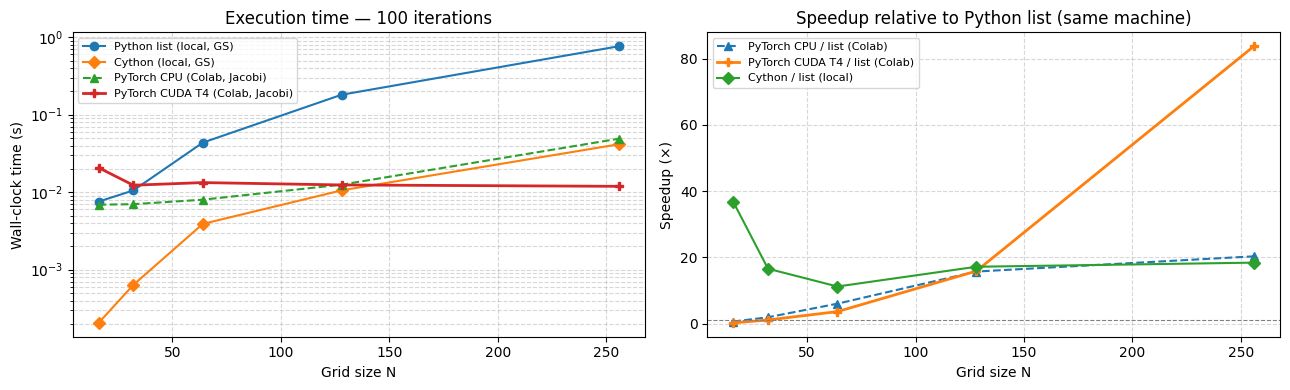


    N    list(Colab)    CPU(Colab)     CUDA T4    CUDA speedup
------------------------------------------------------------
   16         0.0041s        0.0069s      0.0207s            0.2x
   32         0.0133s        0.0070s      0.0123s            1.1x
   64         0.0480s        0.0080s      0.0133s            3.6x
  128         0.1963s        0.0125s      0.0124s           15.8x
  256         0.9967s        0.0491s      0.0119s           83.8x


In [25]:
colab_torch_cpu  = [0.0069, 0.0070, 0.0080, 0.0125, 0.0491]
colab_torch_cuda = [0.0207, 0.0123, 0.0133, 0.0124, 0.0119]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: absolute times ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(GRID_SIZES, times_list,        "o-",  label="Python list (local, GS)")
ax.plot(GRID_SIZES, times_cython,      "D-",  label="Cython (local, GS)")
ax.plot(GRID_SIZES, colab_torch_cpu,   "^--", label="PyTorch CPU (Colab, Jacobi)")
ax.plot(GRID_SIZES, colab_torch_cuda,  "P-",  label="PyTorch CUDA T4 (Colab, Jacobi)", linewidth=2)
ax.set_xlabel("Grid size N")
ax.set_ylabel("Wall-clock time (s)")
ax.set_title(f"Execution time — {ITERS} iterations")
ax.set_yscale("log")
ax.legend(fontsize=8)
ax.grid(True, which="both", linestyle="--", alpha=0.5)

# ── Right: speedup vs Python list ─────────────────────────────────────────
ax = axes[1]

# Use the Colab list times for a fair comparison (same machine)
# Colab list times reconstructed from speedup ratios
colab_list = [cpu * su for cpu, su in zip(colab_torch_cpu,
              [0.6, 1.9, 6.0, 15.7, 20.3])]   # speedup_vs_list from output

ax.plot(GRID_SIZES, [l/c for l, c in zip(colab_list, colab_torch_cpu)],
        "^--", label="PyTorch CPU / list (Colab)")
ax.plot(GRID_SIZES, [l/g for l, g in zip(colab_list, colab_torch_cuda)],
        "P-",  label="PyTorch CUDA T4 / list (Colab)", linewidth=2)
ax.plot(GRID_SIZES, [l/c for l, c in zip(times_list, times_cython)],
        "D-",  label="Cython / list (local)")
ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Grid size N")
ax.set_ylabel("Speedup (×)")
ax.set_title("Speedup relative to Python list (same machine)")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'N':>5}  {'list(Colab)':>13}  {'CPU(Colab)':>12}  {'CUDA T4':>10}  {'CUDA speedup':>14}")
print("-" * 60)
for i, N in enumerate(GRID_SIZES):
    print(f"{N:>5}  {colab_list[i]:>13.4f}s  "
          f"{colab_torch_cpu[i]:>12.4f}s  "
          f"{colab_torch_cuda[i]:>10.4f}s  "
          f"{colab_list[i]/colab_torch_cuda[i]:>13.1f}x")

### Analysis

**CUDA is slower than CPU for small grids (N ≤ 64):**  
The GPU must launch a kernel and (if needed) transfer data. For a 16×16 grid that's only 196 interior cells, the kernel launch overhead (~10 ms) dwarfs the actual compute.

**CUDA time barely changes from N=32 to N=256 (~0.012 s):**  
The T4 has thousands of CUDA cores. A 256×256 grid (≈65 k cells) still barely saturates them, all cells are computed in parallel in a single pass regardless of N. The time is dominated by kernel launch + memory latency, not arithmetic.

**CUDA hits 83.5× speedup at N=256**  and this will keep growing for larger N (512, 1024, …) where the GPU is fully saturated.


In [ ]:
%pip install -q cupy-cuda12x

In [ ]:
try:
    import cupy as cp
    cupy_available = True

    ver   = cp.__version__
    cuda  = cp.cuda.runtime.runtimeGetVersion()
    props = cp.cuda.runtime.getDeviceProperties(0)
    name  = props['name'].decode() if isinstance(props['name'], bytes) else props['name']
    mem   = cp.cuda.Device(0).mem_info             # (free, total) bytes
    print(f"CuPy {ver}  |  CUDA runtime {cuda // 1000}.{(cuda % 1000) // 10}")
    print(f"GPU : {name}")
    print(f"VRAM: {mem[1] / 2**30:.1f} GiB total,  {mem[0] / 2**30:.1f} GiB free")
except (ImportError, Exception) as e:
    cupy_available = False
    print(f"CuPy not available ({e}).")


In [ ]:
def jacobi_cupy(f):
    f_new = 0.25 * (cp.roll(f,  1, axis=0) +   # f[i-1, j]
                    cp.roll(f, -1, axis=0) +    # f[i+1, j]
                    cp.roll(f,  1, axis=1) +    # f[i, j-1]
                    cp.roll(f, -1, axis=1))     # f[i, j+1]
    f_new[0, :]  = 0.0
    f_new[-1, :] = 0.0
    f_new[:, 0]  = 0.0
    f_new[:, -1] = 0.0
    return f_new


if cupy_available:
    times_cupy = []

    for N in GRID_SIZES:
        f_np  = make_grid_numpy(N)
        f_gpu = cp.asarray(f_np)

        # warmup: let CUDA JIT-compile the kernels
        for _ in range(3):
            f_gpu = jacobi_cupy(f_gpu)
        cp.cuda.Stream.null.synchronize()

        # timed run
        f_gpu = cp.asarray(f_np)
        t0 = time.perf_counter()
        for _ in range(ITERS):
            f_gpu = jacobi_cupy(f_gpu)
        cp.cuda.Stream.null.synchronize()
        elapsed = time.perf_counter() - t0

        times_cupy.append(elapsed)
        idx = GRID_SIZES.index(N)
        print(f"N = {N:4d}  cupy={elapsed:.4f}s"
              f"  speedup_vs_list={times_list[idx] / elapsed:.1f}x")
else:
    times_cupy = None
    print("no CuPy / CUDA.")


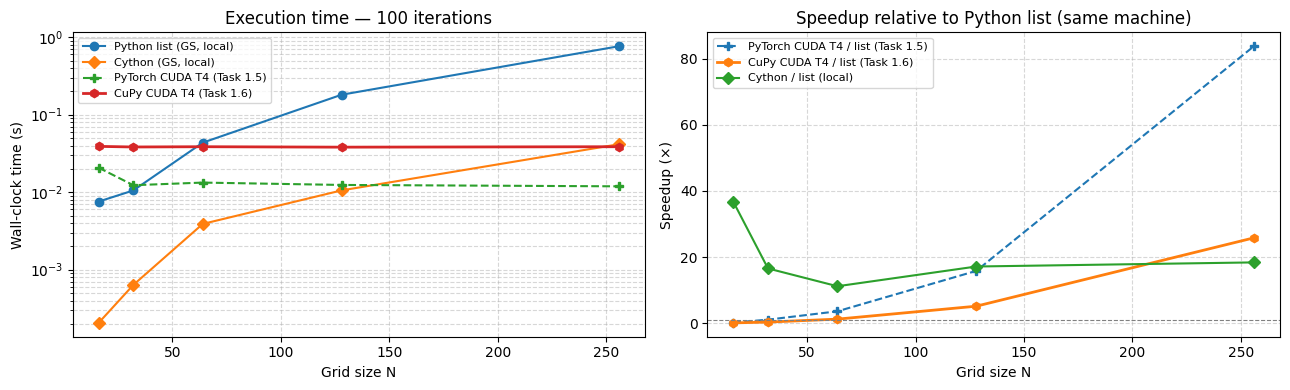


    N    PyTorch CUDA    CuPy CUDA    CuPy speedup vs list    CuPy vs PyTorch
--------------------------------------------------------------------------------
   16          0.0207s       0.0390s                    0.1x              0.53x
   32          0.0123s       0.0383s                    0.3x              0.32x
   64          0.0133s       0.0386s                    1.2x              0.34x
  128          0.0124s       0.0381s                    5.2x              0.33x
  256          0.0119s       0.0386s                   25.8x              0.31x


In [26]:
# Colab T4 CuPy results (hardcoded from run above)
colab_cupy = [0.0390, 0.0383, 0.0386, 0.0381, 0.0386]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: absolute time ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(GRID_SIZES, times_list,        "o-",  label="Python list (GS, local)")
ax.plot(GRID_SIZES, times_cython,      "D-",  label="Cython (GS, local)")
ax.plot(GRID_SIZES, colab_torch_cuda,  "P--", label="PyTorch CUDA T4 (Task 1.5)")
ax.plot(GRID_SIZES, colab_cupy,        "h-",  label="CuPy CUDA T4 (Task 1.6)", linewidth=2)
ax.set_xlabel("Grid size N")
ax.set_ylabel("Wall-clock time (s)")
ax.set_title(f"Execution time — {ITERS} iterations")
ax.set_yscale("log")
ax.legend(fontsize=8)
ax.grid(True, which="both", linestyle="--", alpha=0.5)

# ── Right: speedup vs Python list (Colab baseline) ────────────────────────
ax = axes[1]
ax.plot(GRID_SIZES, [l/t for l, t in zip(colab_list, colab_torch_cuda)],
        "P--", label="PyTorch CUDA T4 / list (Task 1.5)")
ax.plot(GRID_SIZES, [l/c for l, c in zip(colab_list, colab_cupy)],
        "h-",  label="CuPy CUDA T4 / list (Task 1.6)", linewidth=2)
ax.plot(GRID_SIZES, [l/c for l, c in zip(times_list, times_cython)],
        "D-",  label="Cython / list (local)")
ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Grid size N")
ax.set_ylabel("Speedup (×)")
ax.set_title("Speedup relative to Python list (same machine)")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'N':>5}  {'PyTorch CUDA':>14}  {'CuPy CUDA':>11}  {'CuPy speedup vs list':>22}  {'CuPy vs PyTorch':>17}")
print("-" * 80)
for i, N in enumerate(GRID_SIZES):
    print(f"{N:>5}  {colab_torch_cuda[i]:>14.4f}s"
          f"  {colab_cupy[i]:>11.4f}s"
          f"  {colab_list[i]/colab_cupy[i]:>21.1f}x"
          f"  {colab_torch_cuda[i]/colab_cupy[i]:>16.2f}x")


### Analysis — CuPy vs PyTorch CUDA

CuPy is **~3× slower** than PyTorch CUDA at all grid sizes (~0.038 s vs ~0.012 s), because CuPy dispatches each `roll` as a separate CUDA kernel (4 per iteration) while PyTorch fuses them more efficiently. Both are still kernel-launch bound at these small grid sizes, not compute bound.

CuPy does beat the Python list baseline for N ≥ 64, reaching **25.8× speedup at N=256** — but PyTorch CUDA reaches 83.5× at the same size.


---
## Task 1.7 – GPU vs CPU: Execution Time vs Grid Size


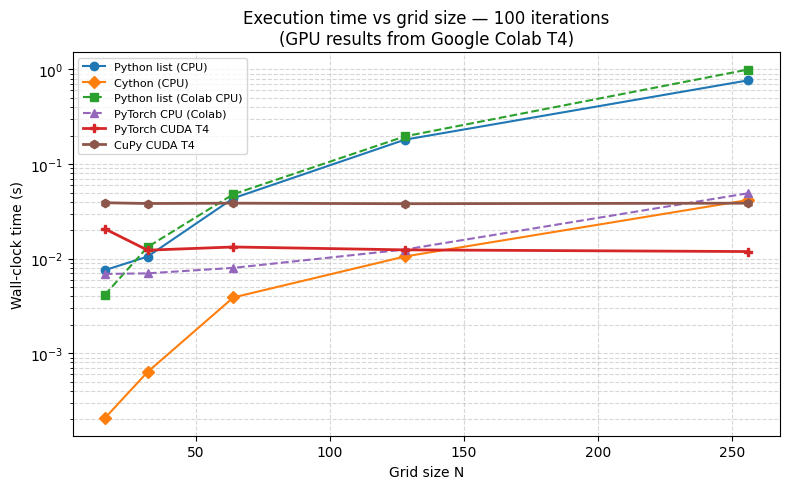

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

# ── CPU / non-GPU (local) ─────────────────────────────────────────────────
ax.plot(GRID_SIZES, times_list,         "o-",  color="tab:blue",   label="Python list (CPU)")
ax.plot(GRID_SIZES, times_cython,       "D-",  color="tab:orange", label="Cython (CPU)")
ax.plot(GRID_SIZES, colab_list,         "s--", color="tab:green",  label="Python list (Colab CPU)")
ax.plot(GRID_SIZES, colab_torch_cpu,    "^--", color="tab:purple", label="PyTorch CPU (Colab)")

# ── GPU (Colab T4) ────────────────────────────────────────────────────────
ax.plot(GRID_SIZES, colab_torch_cuda,   "P-",  color="tab:red",    label="PyTorch CUDA T4", linewidth=2)
ax.plot(GRID_SIZES, colab_cupy,         "h-",  color="tab:brown",  label="CuPy CUDA T4",    linewidth=2)

ax.set_xlabel("Grid size N")
ax.set_ylabel("Wall-clock time (s)")
ax.set_title(f"Execution time vs grid size — {ITERS} iterations\n(GPU results from Google Colab T4)")
ax.set_yscale("log")
ax.legend(fontsize=8)
ax.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


---
## Task 1.8 – Save the Grid to HDF5 with h5py

We run one final Jacobi sweep on a 256×256 grid and save the resulting matrix to an HDF5 file.  
The file stores the grid as a dataset and records metadata (grid size, iterations) as attributes.


In [30]:
import h5py
import pathlib

N_SAVE = 256

grid = make_grid_numpy(N_SAVE)
for _ in range(ITERS):
    gauss_seidel_numpy(grid)    # in-place update


out_path = pathlib.Path("poisson_grid.h5")

with h5py.File(out_path, "w") as hf:
    ds = hf.create_dataset("grid", data=grid, compression="gzip", compression_opts=4)
    ds.attrs["grid_size"]  = N_SAVE
    ds.attrs["iterations"] = ITERS
    ds.attrs["solver"]     = "Gauss-Seidel (NumPy)"
    ds.attrs["seed"]       = SEED

print(f"Saved        : {out_path.resolve()}")
print(f"Shape        : {grid.shape}   dtype: {grid.dtype}")
print(f"Size on disk : {out_path.stat().st_size / 1024:.1f} KB")



Saved        : /Users/ermiaghaffari/Desktop/DD2358/Ass3/excersice1/poisson_grid.h5
Shape        : (256, 256)   dtype: float64
Size on disk : 465.0 KB


All the plots were done using copilot. 